# ProductMeasure: Combining Independent True Measures

`ProductMeasure` builds a larger independent true measure from smaller child true measures. If the children have dimensions $d_1, \ldots, d_k$, then the product has total dimension $d = \sum_j d_j$. A single $d$-dimensional QMC point is split into coordinate blocks, each child transform is applied to its own block, and the transformed blocks are concatenated.

In [1]:

from pathlib import Path
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Make the notebook runnable from either the repo root or this demo folder.
REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "qmcpy").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not find the QMCSoftware repository root.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qmcpy.discrete_distribution import DigitalNetB2
from qmcpy.true_measure import Gaussian, ProductMeasure, SciPyWrapper, Uniform, ZeroInflatedExpUniform

warnings.filterwarnings(
    "ignore",
    message="SciPyWrapper joint distribution has no 'logpdf'.*",
    category=UserWarning,
)

FIG_DIR = REPO_ROOT / "demos" / "product_measure" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)


def save_fig(fig, name):
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path.relative_to(REPO_ROOT)}")


## Example 1: Product of two 1D true measures

Here we combine a one-dimensional zero-inflated exponential component with a one-dimensional continuous SciPy uniform marginal. `ProductMeasure` owns one two-dimensional sampler and splits its coordinates into two one-dimensional blocks.

sample shape: (1024, 2)
zero rate in first coordinate: 0.350 (target about 0.35)
second-coordinate mean: 3.500 (target 3.500)
saved demos\product_measure\figures\example1_two_1d_children.png


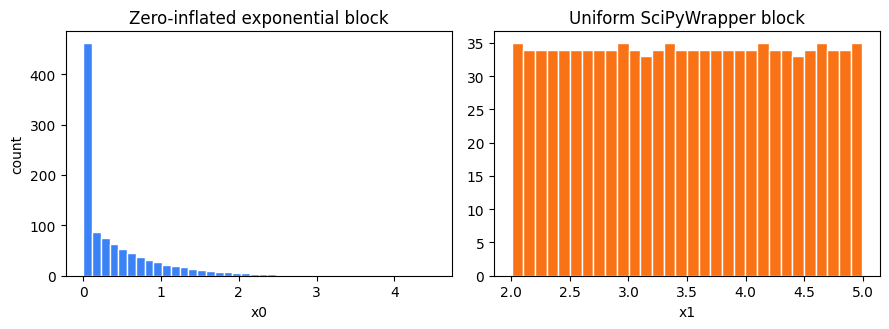

In [3]:

n = 1024
p_zero = 0.35

zero_exp = ZeroInflatedExpUniform(DigitalNetB2(1, seed=11), p_zero=p_zero, lam=1.5)
uniform_1d = SciPyWrapper(DigitalNetB2(1, seed=13), stats.uniform(loc=2.0, scale=3.0))
product_1d = ProductMeasure(
    sampler=DigitalNetB2(2, seed=17),
    children=[zero_exp, uniform_1d],
)

x = product_1d(n)
zero_rate = np.mean(x[:, 0] == 0.0)
second_mean = np.mean(x[:, 1])

print("sample shape:", x.shape)
print(f"zero rate in first coordinate: {zero_rate:.3f} (target about {p_zero:.2f})")
print(f"second-coordinate mean: {second_mean:.3f} (target 3.500)")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].hist(x[:, 0], bins=40, color="#3b82f6", edgecolor="white")
axes[0].set_title("Zero-inflated exponential block")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("count")
axes[1].hist(x[:, 1], bins=30, color="#f97316", edgecolor="white")
axes[1].set_title("Uniform SciPyWrapper block")
axes[1].set_xlabel("x1")
save_fig(fig, "example1_two_1d_children.png")
plt.show()


The product sample has shape `(n, 2)`. The first coordinate comes from `ZeroInflatedExpUniform`; the second coordinate comes from the SciPy uniform true measure.

### Output interpretation

In this example, `ProductMeasure` combines two independent one-dimensional true measures into one two-dimensional true measure. The first coordinate is generated from `ZeroInflatedExpUniform`, and the second coordinate is generated from a SciPy uniform distribution wrapped by `SciPyWrapper`.

The output shape is `(n, 2)` because we generate `n` samples and each sample has two coordinates:

* `x[:, 0]` comes from the zero-inflated exponential component.
* `x[:, 1]` comes from the uniform component on `[2, 5]`.

The zero rate in the first coordinate should be close to the chosen value of `p_zero`. For example, if `p_zero = 0.35`, then about 35% of the first-coordinate samples should be exactly zero. Small differences are normal because we are working with a finite number of samples.

The second-coordinate mean should be close to the mean of `Uniform(2,5)`, which is

$$
\frac{2+5}{2}=3.5.
$$

### Plot interpretation

The first histogram shows the zero-inflated exponential coordinate. The tall bar at zero represents the discrete probability mass: many samples are exactly zero. The positive values form an exponential-like tail.

The second histogram shows the uniform coordinate. Since this coordinate is uniform on `[2,5]`, the bars should be spread fairly evenly across that interval.

Together, the two plots show the purpose of `ProductMeasure`: two different one-dimensional true measures can be combined side by side into one two-dimensional product true measure.


## Example 2: ProductMeasure with replications

Replicated QMC samples are handled along the leading replication axis. The product sampler has `replications=3`, so the product output has shape `(3, n, total_dim)`.

sample shape: (3, 512, 2)
zero rate by replication: [0.4004 0.3984 0.4004]
sample mean by replication:
[[ 0.4843 -0.    ]
 [ 0.4789  0.    ]
 [ 0.4792 -0.    ]]
saved demos\product_measure\figures\example2_replication_zero_rates.png


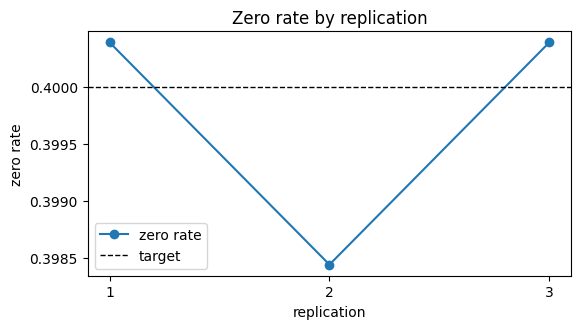

In [4]:

n = 512
r = 3

rep_zero_exp = ZeroInflatedExpUniform(DigitalNetB2(1, seed=21), p_zero=0.4, lam=1.25)
rep_uniform = Uniform(DigitalNetB2(1, seed=23), lower_bound=-1.0, upper_bound=1.0)
rep_product = ProductMeasure(
    sampler=DigitalNetB2(2, seed=25, replications=r),
    children=[rep_zero_exp, rep_uniform],
)

xr = rep_product(n)
zero_rates = np.mean(xr[..., 0] == 0.0, axis=1)
means = np.mean(xr, axis=1)

print("sample shape:", xr.shape)
print("zero rate by replication:", zero_rates)
print("sample mean by replication:")
print(means)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(np.arange(1, r + 1), zero_rates, marker="o", label="zero rate")
ax.axhline(0.4, color="black", linestyle="--", linewidth=1, label="target")
ax.set_xticks(np.arange(1, r + 1))
ax.set_xlabel("replication")
ax.set_ylabel("zero rate")
ax.set_title("Zero rate by replication")
ax.legend()
save_fig(fig, "example2_replication_zero_rates.png")
plt.show()


The replication axis is preserved. Statistics by replication are computed by reducing over the sample axis while keeping the leading axis.

### Output interpretation

This example checks that `ProductMeasure` preserves QMC replications correctly.

With `replications=3`, the output shape is

$$
(3, n, 2).
$$

The first axis is the replication number, the second axis is the sample number within each replication, and the final axis is the product-measure dimension.

So the output can be read as:

* `xr[0, :, :]`: samples from replication 1,
* `xr[1, :, :]`: samples from replication 2,
* `xr[2, :, :]`: samples from replication 3.

The first coordinate is still the zero-inflated exponential coordinate, and the second coordinate is the uniform coordinate.

The printed zero rate by replication shows the fraction of samples equal to zero in each replication. Each value should be close to the target value `p_zero`, but they do not need to be exactly identical. Replications are separate randomized QMC copies, so each one gives a slightly different estimate.

The sample mean by replication shows the average of each coordinate within each replication. This is useful because many QMC error estimates compare results across replications.

### Plot interpretation

The plot shows the zero rate for each replication. The dashed horizontal line is the target zero probability. Points close to this line show that each replication is producing the expected amount of zero mass.

This confirms that `ProductMeasure` is not flattening or losing the replication axis. It keeps the structure `(replications, samples, dimension)` intact.


## Example 3: Different child dimensions

Children do not need to have the same dimension. This example combines a 2D Gaussian true measure with a 1D zero-inflated exponential true measure, so the product sampler has dimension three.

sample shape: (1024, 3)
Gaussian block shape: (1024, 2)
zero-inflated block shape: (1024, 1)
zero rate in third coordinate: 0.300
saved demos\product_measure\figures\example3_different_child_dimensions.png


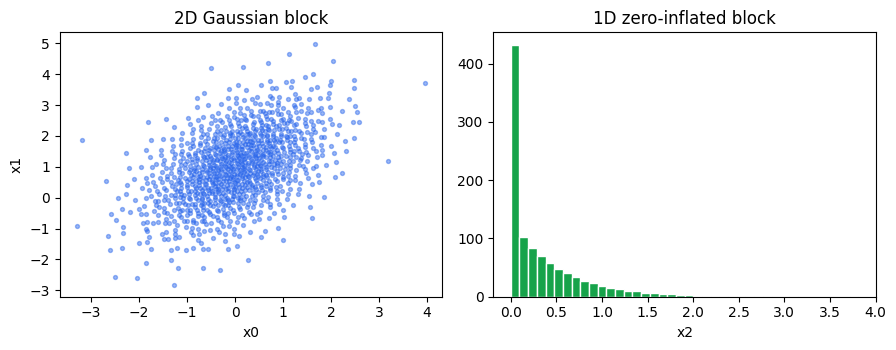

In [5]:

n = 1024

gaussian_2d = Gaussian(
    DigitalNetB2(2, seed=31),
    mean=[0.0, 1.0],
    covariance=[[1.0, 0.6], [0.6, 1.5]],
)
zero_1d = ZeroInflatedExpUniform(DigitalNetB2(1, seed=37), p_zero=0.3, lam=2.0)
product_mixed_dims = ProductMeasure(
    sampler=DigitalNetB2(3, seed=39),
    children=[gaussian_2d, zero_1d],
)

x3 = product_mixed_dims(n)
print("sample shape:", x3.shape)
print("Gaussian block shape:", x3[:, :2].shape)
print("zero-inflated block shape:", x3[:, 2:].shape)
print(f"zero rate in third coordinate: {np.mean(x3[:, 2] == 0.0):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(x3[:, 0], x3[:, 1], s=8, alpha=0.45, color="#2563eb")
axes[0].set_title("2D Gaussian block")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("x1")
axes[1].hist(x3[:, 2], bins=40, color="#16a34a", edgecolor="white")
axes[1].set_title("1D zero-inflated block")
axes[1].set_xlabel("x2")
save_fig(fig, "example3_different_child_dimensions.png")
plt.show()


This is the main convenience of `ProductMeasure`: a child can already be multi-dimensional, and the product treats that child as one independent component block.

### Output interpretation

This example shows why `ProductMeasure` is more general than simply listing one-dimensional marginals. Here, one child true measure is two-dimensional, and the other child true measure is one-dimensional.

The first child is a 2D Gaussian true measure, so it contributes two output coordinates:

$$
(x_0, x_1).
$$

The second child is a 1D zero-inflated exponential true measure, so it contributes one output coordinate:

$$
x_2.
$$

Therefore, the total product-measure dimension is

$$
2 + 1 = 3,
$$

and the output shape is `(n, 3)`.

The printed block shapes confirm this split:

* the Gaussian block has shape `(n, 2)`,
* the zero-inflated block has shape `(n, 1)`.

The zero rate in the third coordinate should be close to the selected zero probability for the zero-inflated exponential component.

### Plot interpretation

The left scatter plot shows the 2D Gaussian block. Because the Gaussian covariance matrix has nonzero off-diagonal entries, the two Gaussian coordinates show correlation, so the point cloud has an elliptical shape rather than a perfectly round shape.

The right histogram shows the zero-inflated exponential block. The spike at zero shows the discrete mass, and the positive values show the exponential tail.

This example demonstrates the main ProductMeasure idea: a multi-dimensional child and a one-dimensional child can be combined as independent blocks without writing a new custom joint distribution.


## Example 4: Product of SciPyWrapper children

`ProductMeasure` also works with children that are themselves `SciPyWrapper` instances. Here the first child wraps two independent SciPy marginals, and the second child wraps one SciPy marginal.

child dimensions: [2 1]
sample shape: (1024, 3)
block means: [-0.      2.9987] 6.505213034913027e-19
saved demos\product_measure\figures\example4_product_of_scipywrappers.png


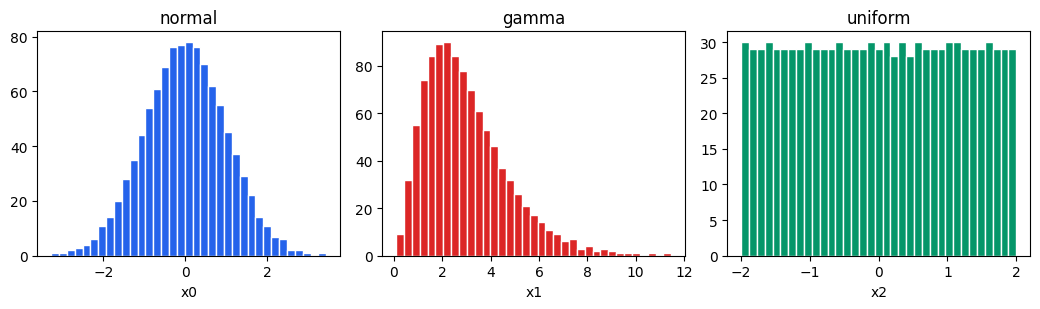

In [6]:

n = 1024

scipy_child_2d = SciPyWrapper(
    DigitalNetB2(2, seed=41),
    [stats.norm(loc=0.0, scale=1.0), stats.gamma(a=3.0, scale=1.0)],
)
scipy_child_1d = SciPyWrapper(
    DigitalNetB2(1, seed=43),
    stats.uniform(loc=-2.0, scale=4.0),
)
product_scipy = ProductMeasure(
    sampler=DigitalNetB2(3, seed=45),
    children=[scipy_child_2d, scipy_child_1d],
)

xs = product_scipy(n)
print("child dimensions:", product_scipy.child_dimensions)
print("sample shape:", xs.shape)
print("block means:", np.mean(xs[:, :2], axis=0), np.mean(xs[:, 2]))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))
labels = ["normal", "gamma", "uniform"]
colors = ["#2563eb", "#dc2626", "#059669"]
for j, ax in enumerate(axes):
    ax.hist(xs[:, j], bins=35, color=colors[j], edgecolor="white")
    ax.set_title(labels[j])
    ax.set_xlabel(f"x{j}")
save_fig(fig, "example4_product_of_scipywrappers.png")
plt.show()


The final dimension is the sum of the child dimensions: the 2D SciPyWrapper block plus the 1D SciPyWrapper block gives a 3D product sample.

### Output interpretation

This example combines two children that are both `SciPyWrapper` true measures.

The first child is a 2D `SciPyWrapper` containing two independent SciPy marginals:

* a normal marginal,
* a gamma marginal.

The second child is a 1D `SciPyWrapper` containing a uniform marginal.

The child dimensions are therefore

$$
(2, 1),
$$

so the total product dimension is

$$
2+1=3.
$$

The output shape is `(n, 3)`. The first two columns come from the first `SciPyWrapper`, and the third column comes from the second `SciPyWrapper`.

The printed means give a quick numerical check that each coordinate is being transformed into the intended marginal distribution.

### Plot interpretation

The three histograms show the three final coordinates:

* the first histogram should look roughly normal,
* the second histogram should look like a gamma distribution, with positive values and right skew,
* the third histogram should look roughly uniform over its specified interval.

This example shows that `ProductMeasure` can combine children that are already composite true measures. A child does not have to be a simple one-dimensional distribution.


## Example 5: ProductMeasure versus one SciPyWrapper

When all components are simple one-dimensional SciPy marginals, one `SciPyWrapper` with a list of marginals is often enough. Here both constructions use the same two-dimensional digital net so the comparison isolates the transform logic rather than sampler differences.

ProductMeasure shape: (4096, 2)
single SciPyWrapper shape: (4096, 2)
ProductMeasure means: [0.9998 1.9998]
single SciPyWrapper means: [0.9998 1.9998]
ProductMeasure correlation: 0.0000
single SciPyWrapper correlation: 0.0000
maximum absolute sample difference: 0.000e+00
saved demos\product_measure\figures\example5_product_vs_single_scipywrapper.png


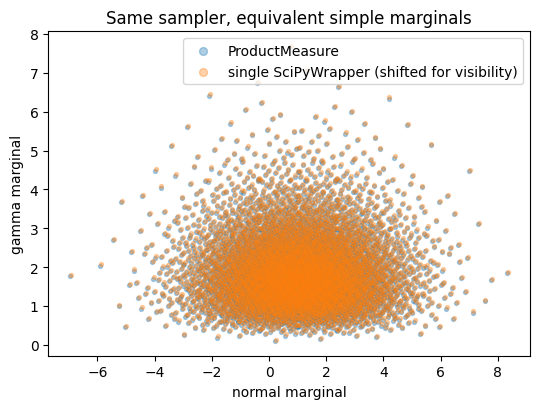

In [7]:

n = 4096
marginals = [stats.norm(loc=1.0, scale=2.0), stats.gamma(a=4.0, scale=0.5)]
seed = 55

product_two_children = ProductMeasure(
    sampler=DigitalNetB2(2, seed=seed),
    children=[
        SciPyWrapper(DigitalNetB2(1, seed=51), marginals[0]),
        SciPyWrapper(DigitalNetB2(1, seed=53), marginals[1]),
    ],
)
one_wrapper = SciPyWrapper(DigitalNetB2(2, seed=seed), marginals)

xp = product_two_children(n)
xw = one_wrapper(n)

print("ProductMeasure shape:", xp.shape)
print("single SciPyWrapper shape:", xw.shape)
print("ProductMeasure means:", np.mean(xp, axis=0))
print("single SciPyWrapper means:", np.mean(xw, axis=0))
print(f"ProductMeasure correlation: {np.corrcoef(xp.T)[0, 1]:.4f}")
print(f"single SciPyWrapper correlation: {np.corrcoef(xw.T)[0, 1]:.4f}")
print(f"maximum absolute sample difference: {np.max(np.abs(xp - xw)):.3e}")

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.scatter(xp[:, 0], xp[:, 1], s=8, alpha=0.35, label="ProductMeasure")
ax.scatter(
    xw[:, 0] + 0.03,
    xw[:, 1] + 0.03,
    s=8,
    alpha=0.35,
    label="single SciPyWrapper (shifted for visibility)",
)
ax.set_xlabel("normal marginal")
ax.set_ylabel("gamma marginal")
ax.set_title("Same sampler, equivalent simple marginals")
ax.legend(markerscale=2)
save_fig(fig, "example5_product_vs_single_scipywrapper.png")
plt.show()


For simple independent SciPy marginals, both approaches agree when they use the same total-dimensional sampler. `ProductMeasure` is more general because a child can itself be a multi-dimensional or custom true measure.

### Output interpretation

This example compares two equivalent constructions for simple independent marginals.

The first construction uses `ProductMeasure`:

$$
\text{ProductMeasure}\left(
\text{SciPyWrapper}(F_1),
\text{SciPyWrapper}(F_2)
\right).
$$

The second construction uses one `SciPyWrapper` with a list of two marginals:

$$
\text{SciPyWrapper}\left([F_1,F_2]\right).
$$

Because both constructions use the same two-dimensional sampler and the same marginal transforms, the output samples should match exactly.

The printed output confirms this:

* both shapes are `(4096, 2)`,
* both sample means match,
* both correlations are close to zero,
* the maximum absolute sample difference is `0.000e+00`.

The zero maximum difference means the two arrays are identical up to numerical precision.

### Plot interpretation

The plot overlays the `ProductMeasure` samples and the single `SciPyWrapper` samples. Since the samples are exactly the same, one color would hide the other if both were plotted at the same location. That is why the single `SciPyWrapper` samples are shifted slightly in the plot for visibility.

The important message is not the small visual shift. The important message is that for simple independent one-dimensional marginals, `ProductMeasure` reproduces the same transformation as one `SciPyWrapper`.

This example also explains why `ProductMeasure` is still useful: unlike one `SciPyWrapper`, it can combine larger child true measures, such as a 2D Gaussian block with a 1D zero-inflated block.


## Example 6: Basic error handling

`ProductMeasure` expects one total-dimensional sampler and a nonempty list or tuple of true measure children. Invalid inputs raise errors before sampling starts.

In [8]:

bad_cases = [
    ("empty child list", DigitalNetB2(1, seed=7), []),
    ("non-true-measure child", DigitalNetB2(1, seed=7), [object()]),
    ("dimension mismatch", DigitalNetB2(2, seed=7), [Uniform(DigitalNetB2(1, seed=9))]),
]
for label, sampler, children in bad_cases:
    try:
        ProductMeasure(sampler=sampler, children=children)
    except Exception as err:
        print(f"{label}: {type(err).__name__}: {err}")


empty child list: ParameterError: ProductMeasure requires a nonempty list of children.
non-true-measure child: ParameterError: Each ProductMeasure child must be an AbstractTrueMeasure instance.
dimension mismatch: DimensionError: ProductMeasure sampler dimension must equal the sum of child dimensions (2 != 1).


These checks catch common setup mistakes: forgetting children, passing objects that are not true measures, or using a sampler whose dimension does not match the sum of child dimensions.

### Output interpretation

This example shows the basic error handling in `ProductMeasure`.

`ProductMeasure` expects two things:

1. A sampler whose dimension equals the total dimension of all child true measures.
2. A nonempty list of valid QMCPy true measure children.

The first invalid case passes an empty child list. This fails because a product measure cannot be built without components.

The second invalid case passes an ordinary Python object instead of a true measure. This fails because `ProductMeasure` needs each child to have the true-measure interface, including dimension, range, transform, and weight behavior.

The third invalid case uses a sampler dimension that does not match the sum of child dimensions. For example, if the children have total dimension 1, the sampler must also have dimension 1. A two-dimensional sampler would provide too many input coordinates.

### Why this matters

These checks catch setup mistakes early, before sampling begins. Without them, dimension mismatches could produce confusing shape errors later in the transform step.

This example shows the required `ProductMeasure` setup:

```math
\text{sampler dimension} = \sum_{j=1}^{k} \text{child dimension}_j.
```

In words, the sampler dimension must equal the total dimension contributed by all child true measures.

